# nClimGrid-Daily 2023


Emma Heienickle Spring 2023 

In [1]:
# Load Libraries: 
import numpy as np
import numpy.ma as ma
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import netCDF4 as nc
import xarray as xr
import os
import geopandas as gpd
import seaborn as sns

# Cartopy/ Mapping: 
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.feature import NaturalEarthFeature
states = NaturalEarthFeature(category="cultural", scale="50m",
                                     facecolor="none",
                                     name="admin_1_states_provinces_lines")

# Mapping / raster data: 
from shapely.geometry import mapping
import rioxarray as rio

import dask # importing multiple data files at once. 

# Scipy Statistics: 
from scipy import stats
from scipy.stats import norm
from scipy.stats import genextreme as gev


**Load Data: 

data is available from 1951-01-01 - 2023-03**

In [2]:
# Load through Xarray - Emma's Office Computer: 
set1900=xr.open_mfdataset('C:/Users/emmaheienickle/OneDrive - Texas A&M University/Untitled Folder/Data/19*/ncdd*.nc',
                          parallel=True)
set2000=xr.open_mfdataset('C:/Users/emmaheienickle/OneDrive - Texas A&M University/Untitled Folder/Data/20*/ncdd*.nc',
                          parallel=True)
climatedata = xr.combine_nested([set1900, set2000], concat_dim=["time"]) # combine

OSError: no files to open

In [3]:
# Load through Xarray - Emma's Laptop: 
# example pull 1 nc file: example = xr.open_mfdataset("/Users/emmaheienickle/Library/CloudStorage/GoogleDrive-emmaheienickle@tamu.edu/My Drive/Research/nclimdiv-d/Data/1951/ncdd-195102-grd-scaled.nc")

set1900=xr.open_mfdataset('/Users/emmaheienickle/Library/CloudStorage/GoogleDrive-emmaheienickle@tamu.edu/My Drive/Research/nclimdiv-d/Data/19*/ncdd*.nc',
                          parallel=True)

set2000=xr.open_mfdataset('/Users/emmaheienickle/Library/CloudStorage/GoogleDrive-emmaheienickle@tamu.edu/My Drive/Research/nclimdiv-d/Data/20*/ncdd*.nc',
                          parallel=True)

climatedata = xr.combine_nested([set1900, set2000], concat_dim=["time"]) # combine

KeyboardInterrupt: 

In [52]:
# check:
climatedata.lon[1]

<xarray.DataArray 'lon' ()>
array(-124.645836, dtype=float32)
Coordinates:
    lon      float32 -124.6
Attributes:
    long_name:      Longitude
    standard_name:  longitude
    units:          degrees_east
    axis:           X
    valid_min:      -124.6875
    valid_max:      -67.020836
    comment:        Resolution is 1/24 degree, equivalent to 4.63 km at the E...

Variables: Time, Lat, Lon, Temperature - Max, Min, Avg, Precipitation

In [3]:
# Get Time Series and work with just the southern region: 
#1981-2010
clim81 = climatedata.sel(lat=slice(26,37), lon=slice(-110,-84)).loc[dict(time=slice("1981-01-01","2010-12-31"))]

#1991-2020
clim91 = climatedata.sel(lat=slice(26,37), lon=slice(-110,-84)).loc[dict(time=slice("1991-01-01","2020-12-31"))]

In [22]:
# Texas Outline: 
gdf_states = gpd.read_file("ne_110m_admin_1_states_provinces.shp")
Texas = gdf_states.loc[gdf_states['name'] == 'Texas']

DriverError: ne_110m_admin_1_states_provinces.shp: No such file or directory

In [29]:
# Cut data to the extent of Texas: 

texasprcp81 = clim81['prcp'].rename({"lat":"y", "lon":"x"}).rio.write_crs("EPSG:4326") # set CRS
texasprcp91 = clim91['prcp'].rename({"lat":"y", "lon":"x"}).rio.write_crs("EPSG:4326") 

texasprcp81 = texasprcp81.rio.clip(Texas.geometry.apply(mapping)) # use rioxarray to clip to Texas geometry 
texasprcp91 = texasprcp91.rio.clip(Texas.geometry.apply(mapping))

NameError: name 'clim81' is not defined

# Precipitation

Time series: 1981-2010 and 1991-2020
Precipitation data collected in mm at the end of each day. 

## **Average 30-Year Precipitation Values:**

In [58]:
example = xr.open_mfdataset("/Users/emmaheienickle/Library/CloudStorage/GoogleDrive-emmaheienickle@tamu.edu/My Drive/Research/nclimdiv-d/Data/2022/ncdd*-grd-scaled.nc",
                           parallel = True)

In [65]:
example

<xarray.Dataset>
Dimensions:  (time: 365, lat: 596, lon: 1385)
Coordinates:
  * time     (time) datetime64[ns] 2022-01-01 2022-01-02 ... 2022-12-31
  * lat      (lat) float32 24.56 24.6 24.65 24.69 ... 49.23 49.27 49.31 49.35
  * lon      (lon) float32 -124.7 -124.6 -124.6 -124.6 ... -67.1 -67.06 -67.02
Data variables:
    tmax     (time, lat, lon) float64 dask.array<chunksize=(31, 596, 1385), meta=np.ndarray>
    tmin     (time, lat, lon) float64 dask.array<chunksize=(31, 596, 1385), meta=np.ndarray>
    prcp     (time, lat, lon) float64 dask.array<chunksize=(31, 596, 1385), meta=np.ndarray>
    tavg     (time, lat, lon) float64 dask.array<chunksize=(31, 596, 1385), meta=np.ndarray>
Attributes: (12/33)
    date_created:               2022-09-02 08:42:38.355979
    date_modified:              2022-09-02 08:42:38.357014
    Conventions:                CF-1.7, ACDD-1.3
    ncei_template_version:      NCEI_NetCDF_Grid_Template_v2.0
    title:                      nClimGrid-Daily, Gridded Fields
    source:                     GHCN-Daily, nClimGrid-Monthly
    ...                         ...
    time_coverage_start:        2022-01-01
    time_coverage_end:          2022-01-31
    program:                    Center for Weather and Climate/Climate Scienc...
    geospatial_lat_resolution:  0.04167 degrees
    geospatial_lon_resolution:  0.04167 degrees
    platform:                   station

In [44]:
# Texas Outline: 
gdf_states = gpd.read_file("/Users/emmaheienickle/Library/CloudStorage/GoogleDrive-emmaheienickle@tamu.edu/My Drive/Research/ne_110m_admin_1_states_provinces.shp")
Texas = gdf_states.loc[gdf_states['name'] == 'Texas']

In [60]:
new = example.prcp.rename({"lat":"y", "lon":"x"}).rio.write_crs("EPSG:4326") # set CRS
new = new.rio.clip(Texas.geometry.apply(mapping)) # use rioxarray to clip to Texas geometry 

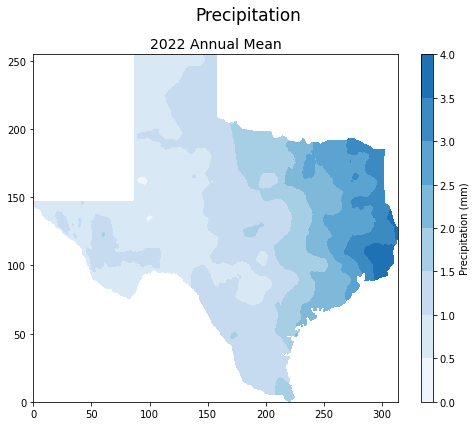

In [61]:

# plot figure:
fig, axs = plt.subplots(1, figsize = (7,6))

# 1981-2010:
mappable = axs.contourf(new.mean('time'), cmap = "Blues", vmin = 0, vmax = 5)
axs.set_title("2022 Annual Mean", size = 14)


# title: 
fig.suptitle("Precipitation", size = 17)
fig.tight_layout()
cb = plt.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

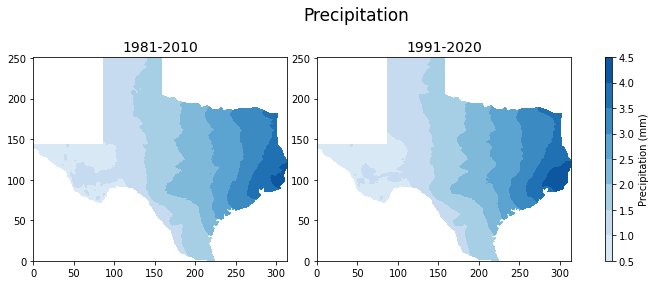

In [330]:
# Average 30-Year Precipitation:

# Pulls the mean precipitation value for each grid point over the 30-year period: 
prcp_mean_1981 = texasprcp81.mean('time') 
prcp_mean_1991 = texasprcp91.mean('time')

# plot figure:
fig, axs = plt.subplots(1,2, figsize = (10,4))

# 1981-2010:
mappable = axs[0].contourf(prcp_mean_1981, cmap = "Blues", vmin = 0, vmax = 5)
axs[0].set_title("1981-2010", size = 14)

# 1991-2020:
mappable2 = axs[1].contourf(prcp_mean_1991, cmap = "Blues", vmin = 0, vmax = 5)
axs[1].set_title("1991-2020", size = 14)

# title: 
fig.suptitle("Precipitation", size = 17)
fig.tight_layout()
cb = plt.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

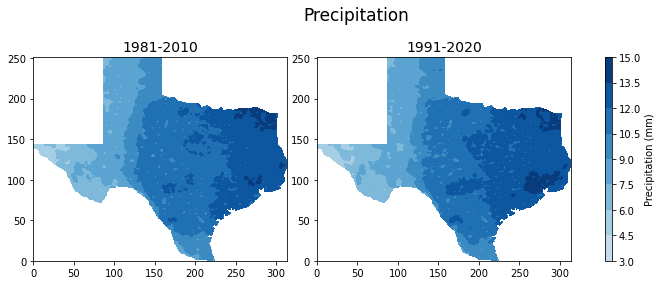

In [31]:
# Average 30-Year Precipitation when it did rain:
# pulling just wet days (precipitation not equal to zero)

# pulls the mean precipitation value for each grid point over the 30-year period: 
wetprcp_mean_1981 = texasprcp81.where(texasprcp81 >= 0).mean('time') 
wetprcp_mean_1991 = texasprcp91.where(texasprcp81 >= 0).mean('time')

# plot figure:
fig, axs = plt.subplots(1,2, figsize = (10,4))

# 1981-2010:
mappable = axs[0].contourf(wetprcp_mean_1981, cmap = "Blues", vmin = 0, vmax = 15)
axs[0].set_title("1981-2010", size = 14)

# 1991-2020:
mappable2 = axs[1].contourf(wetprcp_mean_1991, cmap = "Blues", vmin = 0, vmax = 15)
axs[1].set_title("1991-2020", size = 14)

# title: 
fig.suptitle("Precipitation", size = 17)
fig.tight_layout()
cb = plt.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

**Average Precipitation Difference between 2 30-Year Periods**

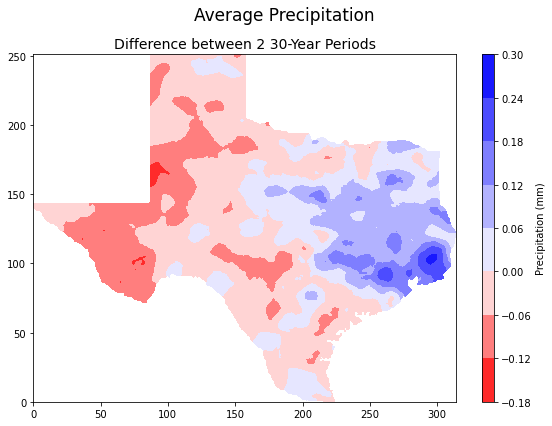

In [180]:
# Average Precipitation Difference: #1991-2020 - 1981-2010:

# Difference between 2 precipitation rasters: 
meanprcpdif = (prcp_mean_1991 - prcp_mean_1981)

# Plot figure:
fig, axs = plt.subplots(1, figsize = (8, 6))

# Precip difference: 
norm = TwoSlopeNorm(vcenter=0)
mappable = axs.contourf(meanprcpdif, cmap = "bwr_r", norm=norm)
axs.set_title("Difference between 2 30-Year Periods", size = 14)

fig.suptitle("Average Precipitation", size = 17)
fig.tight_layout()
cb = fig.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

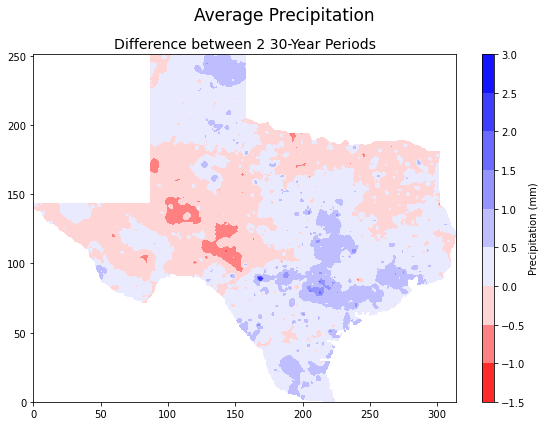

In [34]:
# Rainy Day Precipitation: 

wetmeanprcpdif = (wetprcp_mean_1991 - wetprcp_mean_1981)

# Plot figure:
fig, axs = plt.subplots(1, figsize = (8, 6))

# Precip difference: 
norm = TwoSlopeNorm(vcenter=0)
mappable = axs.contourf(wetmeanprcpdif, cmap = "bwr_r", norm=norm)
axs.set_title("Difference between 2 30-Year Periods", size = 14)

# title: 
fig.suptitle("Average Precipitation", size = 17)
fig.tight_layout()
cb = fig.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

 ## **Maximum Precipitation**

selects the extreme event, the day with the greatest rainfall per gridcell


In [46]:
# Pulls the max precipitation value for each grid point over the 30-year period: 
prcp_max_1981 = texasprcp81.max('time') 
prcp_max_1991  = texasprcp91.max('time')

# convert to panda dataframe: 
max81df = prcp_max_1981.to_dataframe()
max91df = prcp_max_1991.to_dataframe()

In [47]:
max81df.describe()

,spatial_ref,prcp
count,79380.0,37294.000000
mean,0.0,121.169316
std,0.0,43.352813
min,0.0,33.976562
25%,0.0,91.882812
50%,0.0,115.523438
75%,0.0,144.078125
max,0.0,287.453125


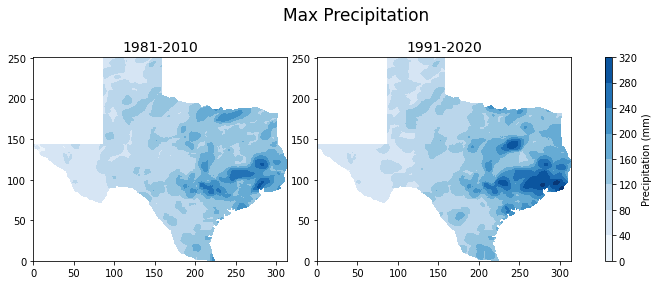

In [14]:
# Maximum 30-Year Precipitation:

# plot figure:
fig, axs = plt.subplots(1,2, figsize = (10,4))

# 1981-2010:
mappable = axs[0].contourf(prcp_max_1981, cmap = "Blues", vmin=0, vmax=350)
axs[0].set_title("1981-2010", size = 14)

# 1991-2020:
mappable2 = axs[1].contourf(prcp_max_1991, cmap = "Blues", vmin=0, vmax=350)
axs[1].set_title("1991-2020", size = 14)

# title: 
fig.suptitle("Max Precipitation", size = 17)
fig.tight_layout()
cb = plt.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

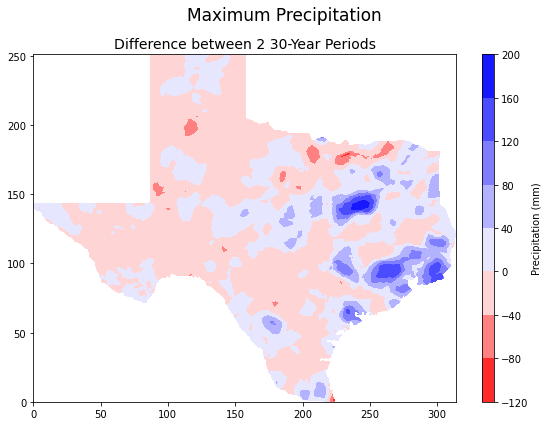

In [174]:
# Max Precipitation Difference: # 1991-2020 - 1981-2010:

# Difference between 2 precipitation rasters: 
maxprcpdif = (prcp_max_1991 - prcp_max_1981)

# Plot figure:
fig, axs = plt.subplots(1, figsize = (8, 6))

# Precip difference: 
norm = TwoSlopeNorm(vcenter=0)
mappable = axs.contourf(maxprcpdif, cmap = "bwr_r", norm=norm)
axs.set_title("Difference between 2 30-Year Periods", size = 14)

# title: 
fig.suptitle("Maximum Precipitation", size = 17)
fig.tight_layout()
cb = fig.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

## **Wettest Year per Grid Cell**

want to see how the total precipitation data varies spatially, 
does every grid cell recieve the most amount of precipitation in the same year, or do the grid cells vary drastically?

sums the precipitation by year for every grid cell

In [6]:
# 1980-2010 Wettest Year:
precip_by_year81 = texasprcp81.groupby('time.year').sum() 
wettest81year = precip_by_year81.argmax(dim="year") # finds when the maximum precipitation value was obtained
#wettest81yearma = wettest81year.where(wettest81year != 0) # want to mask the surrounding texas areas / borders so they do not get a color : 
wettest81yearma = wettest81year.rio.clip(Texas.geometry.apply(mapping)) # use rioxarray to clip to Texas geometry 


# 1990-2020 Wettest Year:
precip_by_year91 = texasprcp91.groupby('time.year').sum()
wettest91year = precip_by_year91.argmax(dim="year") # finds when the maximum precipitation value was obtained
#wettest91yearma = wettest91year.where(wettest91year != 0)# want to mask the surrounding texas areas / borders so they do not get a color : 
wettest91yearma = wettest91year.rio.clip(Texas.geometry.apply(mapping))
wettest91yearma = (wettest91yearma + 10) # setting the second time frame with an index of +10 to get the 2 30-year periods on the same scale to be plotted against each other. 

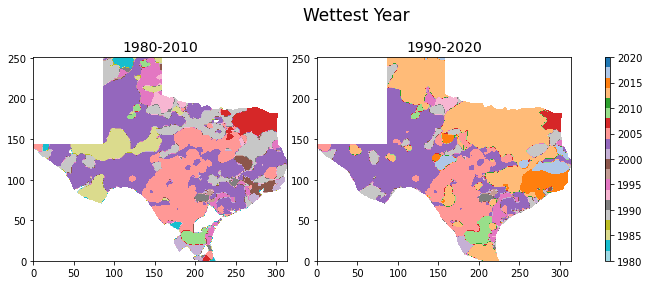

In [7]:
# Wettest Year: 1980-2010 and 1990-2020: Plot: 

labels = np.arange(1980,2021,5)

# Plot Fig:
fig, axs = plt.subplots(1, 2, figsize = (10, 4))

mappable = axs[0].contourf(wettest81yearma, cmap="tab20_r", levels = np.arange(0,41,1), vmin=0, vmax=40)  # shows the index of the wettest year  0 = 1981, 1 = 1999, etc. 
axs[0].set_title("1980-2010", size = 14)

axs[1].contourf(wettest91yearma, cmap="tab20_r", levels = np.arange(0,41,1), vmin=0, vmax=40)  # shows the index of the wettest year  0 = 1981, 1 = 1999, etc. 
axs[1].set_title("1990-2020", size = 14)

fig.suptitle("Wettest Year", size = 17)
fig.tight_layout() 

cb = fig.colorbar(mappable, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cb.set_ticklabels(labels)

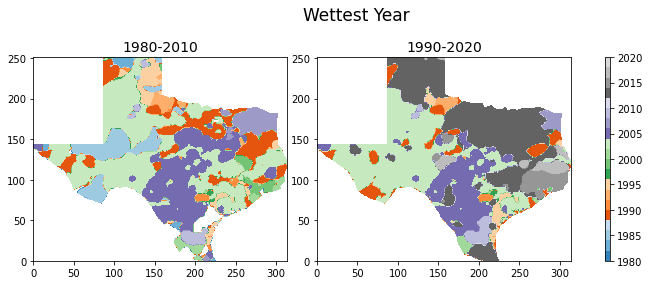

In [48]:
# Wettest Year: 1980-2010 and 1990-2020: Plot: 

labels = np.arange(1980,2021,5)

# Plot Fig:
fig, axs = plt.subplots(1, 2, figsize = (10, 4))

mappable = axs[0].contourf(wettest81yearma, cmap="tab20c_r", levels = np.arange(0,41,1), vmin=0, vmax=40)  # shows the index of the wettest year  0 = 1981, 1 = 1999, etc. 
axs[0].set_title("1980-2010", size = 14)

axs[1].contourf(wettest91yearma, cmap="tab20c_r", levels = np.arange(0,41,1), vmin=0, vmax=40)  # shows the index of the wettest year  0 = 1981, 1 = 1999, etc. 
axs[1].set_title("1990-2020", size = 14)

fig.suptitle("Wettest Year", size = 17)
fig.tight_layout() 

cb = fig.colorbar(mappable, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cb.set_ticklabels(labels)

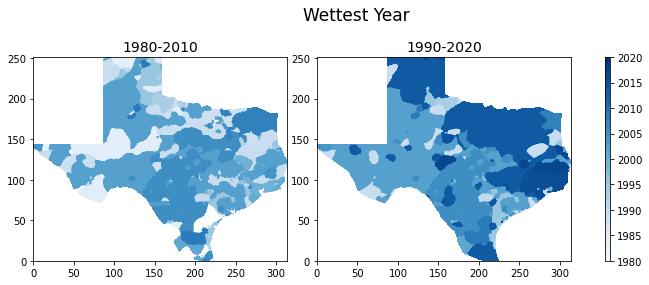

In [46]:
# Wettest Year: 1980-2010 and 1990-2020: Plot: 

labels = np.arange(1980,2021,5)

# Plot Fig:
fig, axs = plt.subplots(1, 2, figsize = (10, 4))

mappable = axs[0].contourf(wettest81yearma, cmap="Blues", levels = np.arange(0,41,1), vmin=0, vmax=40)  # shows the index of the wettest year  0 = 1981, 1 = 1999, etc. 
axs[0].set_title("1980-2010", size = 14)

axs[1].contourf(wettest91yearma, cmap="Blues", levels = np.arange(0,41,1), vmin=0, vmax=40)  # shows the index of the wettest year  0 = 1981, 1 = 1999, etc. 
axs[1].set_title("1990-2020", size = 14)

fig.suptitle("Wettest Year", size = 17)
fig.tight_layout() 

cb = fig.colorbar(mappable, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cb.set_ticklabels(labels)

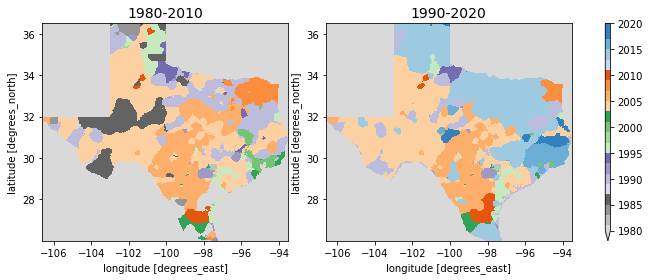

In [8]:
# Wettest Year: 1980-2010 and 1990-2020: Plot: 

labels = np.arange(1980,2021,5)

# Plot Fig: 
fig, axs = plt.subplots(1, 2, figsize = (10,4))

mappable = wettest81yearma.plot.pcolormesh(ax=axs[0], cmap="tab20c_r", levels = np.arange(0,41,1), vmin=0, vmax=40, add_colorbar=False)  
axs[0].set_title("1980-2010", size = 14)

wettest91yearma.plot.pcolormesh(ax=axs[1], cmap="tab20c_r", levels = np.arange(0,41,1), vmin=0, vmax=40, add_colorbar=False)  
axs[1].set_title("1990-2020", size = 14)

fig.tight_layout() 

cb = fig.colorbar(mappable, ax=axs, orientation="vertical", aspect=40)
cb.set_ticklabels(labels)

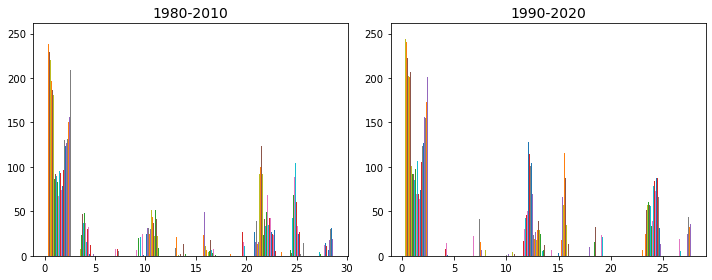

In [48]:
# histogram: what year captures the most grid cells

# Plot Fig: 
fig, ax = plt.subplots(1,2, figsize = (10,4))

ax[0].hist(wettest81year)  
ax[0].set_title("1980-2010", size = 14)

ax[1].hist(wettest91year)  
ax[1].set_title("1990-2020", size = 14)


fig.tight_layout() 

cb = fig.colorbar(mappable, ax=axs, orientation="vertical", aspect=40)
cb.set_ticklabels(labels)

In [ ]:
colors = ["#201923","#ffffff","#fcff5d","#7dfc00","#0ec434","#228c68","#8ad8e8","#235b54","#29bdab","#3998f5","#37294f",
          "#277da7","#3750db","#f22020","#991919", "#ffcba5","#e68f66","#c56133","#96341c","#632819","#ffc413","#f47a22",
          "#2f2aa0","#b732cc","#772b9d","#f07cab","#d30b94","#edeff3","#c3a5b4","#946aa2","#5d4c86"]

# Annual Maximum Series

Maximum precipitation value for Texas is pulled for each year 

In [9]:
# Finds maximum precipitation across grid cells over 30-year period (daily data)
prcp_max_1981 = texasprcp81.max(['y','x']) # 1 value for every time step/1 value for all of Texas
prcp_max_1991  = texasprcp91.max(['y','x'])

# pulls the max value for each year: 
ams1981 = prcp_max_1981.groupby("time.year").max()
ams1991 = prcp_max_1991.groupby("time.year").max()

In [10]:
# convert to panda dataframe to see the max. precipitation values for every year for Texas: 
ams81df = ams1981.to_dataframe()
ams81df["prcp"]

year
1981    249.031250
1982    231.640625
1983    173.289062
1984    231.476562
1985    173.078125
1986    138.273438
1987    147.632812
1988    145.539062
1989    198.007812
1990    192.507812
1991    135.570312
1992    127.921875
1993    161.210938
1994    287.453125
1995    191.703125
1996    160.109375
1997    207.929688
1998    268.148438
1999    164.562500
2000    144.078125
2001    223.859375
2002    141.726562
2003    165.250000
2004    164.679688
2005    230.171875
2006    182.507812
2007    203.992188
2008    162.546875
2009    202.710938
2010    223.031250
Name: prcp, dtype: float64

In [11]:
# convert to panda dataframe to see the max. precipitation values for every year for Texas: 
ams91df = ams1991.to_dataframe()
ams91df["prcp"]

year
1991    135.570312
1992    127.921875
1993    161.210938
1994    287.453125
1995    191.703125
1996    160.109375
1997    207.929688
1998    268.148438
1999    164.562500
2000    144.078125
2001    223.859375
2002    141.726562
2003    165.250000
2004    164.679688
2005    230.171875
2006    182.507812
2007    203.992188
2008    162.546875
2009    202.710938
2010    223.031250
2011    208.453125
2012    189.968750
2013    262.750000
2014    185.640625
2015    304.359375
2016    239.710938
2017    334.367188
2018    209.757812
2019    339.960938
2020    198.742188
Name: prcp, dtype: float64

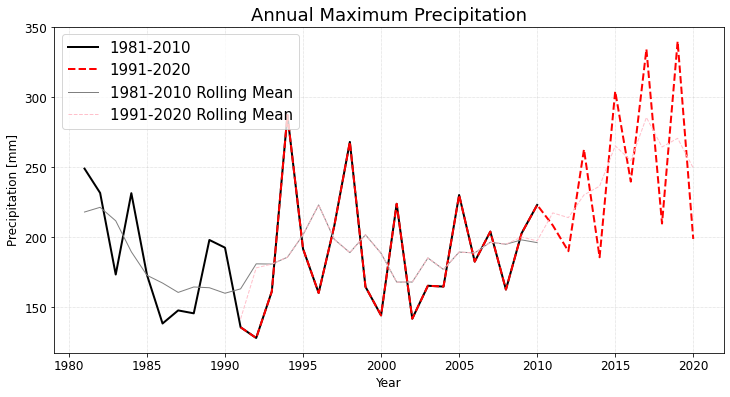

In [10]:
# Annual Maximum Precipitation for Texas: 

# Calculate Rolling Mean: 
rolling = ams81df.rolling(min_periods = 2, window = 5, center=True).mean()
rolling2 = ams91df.rolling(min_periods = 2, window = 5, center=True).mean()

# plot: 
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(ams81df["prcp"], lw=2, color='black', label="1981-2010")
ax.plot(ams91df["prcp"], lw=2, color='red', linestyle = "dashed", label="1991-2020")
ax.plot(rolling["prcp"], lw=1, color='grey', label="1981-2010 Rolling Mean")
ax.plot(rolling2["prcp"], lw=1, color='pink',linestyle = "dashed", label="1991-2020 Rolling Mean")


# set tick label size for both x and y
ax.tick_params(labelsize=12)

# set x and y axis labels and title
ax.set_ylabel(r'Precipitation [mm]', fontsize=12);
ax.set_xlabel(r'Year', fontsize=12);
ax.set_title("Annual Maximum Precipitation", fontsize=18)

# set grid
ax.grid(lw=0.5, ls="dotted")

# set legend
ax.legend(fontsize=15)

## Generalized Extreme Value Distribution: 


In [11]:
# data array: texasprcp81 and texasprcp91
# ams data array: ams1981 and ams1991 
# panda data frames: ams81df and ams91df

print("1981-2010 Statistics")

# Mean (Location Parameter)
print("Mean: ", ams81df["prcp"].mean())

# Median (Location Parameter)
print("Median:", ams81df["prcp"].median())

# Variance (Scale Parameter)
print("Variance: ", ams81df["prcp"].var())

# Skewness (Shape Parameter)
print("Skewness:", ams81df["prcp"].skew())

# Kurtosis (Shape Parameter)
print("Kurtosis:", ams81df["prcp"].kurtosis())

1981-2010 Statistics
Mean:  187.6546875
Median: 177.8984375
Variance:  1713.202970938847
Skewness: 0.6312541274816305
Kurtosis: -0.2759014574237182


In [79]:
print("1991-2020 Statistics")

# Mean (Location Parameter)
print("Mean: ", ams91df["prcp"].mean())

# Median (Location Parameter)
print("Median:", ams91df["prcp"].median())

# Variance (Scale Parameter)
print("Variance: ", ams91df["prcp"].var())

# Skewness (Shape Parameter)
print("Skewness:", ams91df["prcp"].skew())

# Kurtosis (Shape Parameter)
print("Kurtosis:", ams91df["prcp"].kurtosis())

1991-2020 Statistics
Mean:  207.42916666666667
Median: 200.7265625
Variance:  3162.4335766320937
Skewness: 0.8868361420682624
Kurtosis: 0.2575336152346508


187.6546875 40.69516193899326


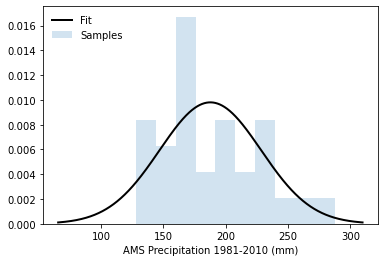

207.42916666666667 55.29031672976463


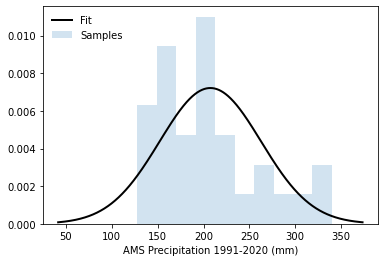

In [12]:
# Fit the dataset into the distribution: 

from scipy.stats import genextreme as gev

## 1981 - 2010
samples = ams81df["prcp"] #  dataset

mu, sigma = norm.fit(samples, method="MLE")  # do a maximum-likelihood fit
print(mu, sigma)

# Plot figure 1: 
bins = np.arange(mu - 3 * sigma, mu + 3 * sigma, 0.01)
plt.hist(samples, density=True, histtype='stepfilled',
         alpha=0.2, label='Samples')
plt.plot(bins, norm.pdf(bins, loc=mu, scale=sigma),
         'k-', lw=2, label='Fit')
plt.legend(loc='best', frameon=False)
plt.xlabel("AMS Precipitation 1981-2010 (mm)")
plt.show()

## 1991 - 2020
sample2 = ams91df["prcp"] # pesudo dataset
mu2, sigma2 = norm.fit(sample2, method="MLE")  # do a maximum-likelihood fit
print(mu2, sigma2)

# Plot figure 2: 
bins2 = np.arange(mu2 - 3 * sigma2, mu2 + 3 * sigma2, 0.01)
plt.hist(sample2, density=True, histtype='stepfilled',
         alpha=0.2, label='Samples')
plt.plot(bins2, norm.pdf(bins2, loc=mu2, scale=sigma2),
         'k-', lw=2, label='Fit')
plt.legend(loc='best', frameon=False)
plt.xlabel("AMS Precipitation 1991-2020 (mm)")
plt.show()

In [13]:
# 1981 - 2010 
yr81 = prcp_max_1981.groupby("time.year").sum() # aggregate annual rainfall total

# 1991 - 2020 
yr91 = prcp_max_1991.groupby("time.year").sum() # aggregate annual rainfall total

Kendall’s tau is a measure of the correspondence between two rankings. 

Values close to 1 indicate strong agreement, and values close to -1 indicate strong disagreement.



P-value shows how likely it is that your set of observations could have occurred under the null hypothesis. P-Values are used in statistical hypothesis testing to determine whether to reject the null hypothesis. The smaller the p-value, the stronger the likelihood that you should reject the null hypothesisM, the more significant your results are. 

In [15]:
print("1981-2010")
tau1, p1 = stats.kendalltau(yr81["year"], yr81) # tau is Kendall’s tau measure and p is the corresponding p-value
print("81:", "Tau:", tau1, "P-Value:", p1)

c0, loc0, scale0  = gev.fit(ams81df["prcp"], method="MLE")
print("Location:", loc0, "Scale", scale0, "Shape:", c0)
MLEGEV = gev(c0, loc=loc0, scale=scale0)  # Frozen distribution


#####
print("1991-2020")

tau2, p2 = stats.kendalltau(yr91["year"], yr91) 
print("91:", "Tau:", tau2, "P-Value:", p2)

c0, loc0, scale0  = gev.fit(ams91df["prcp"], method="MLE")
print("Location:", loc0, "Scale", scale0, "Shape:", c0)
MLEGEV2 = gev(c0, loc=loc0, scale=scale0)

1981-2010
81: Tau: -0.1632183908045977 P-Value: 0.21370025661362413
Location: 168.36726753413004 Scale 32.289854121902266 Shape: -0.012897177616997192
1991-2020
91: Tau: 0.020689655172413793 P-Value: 0.8875122085953918
Location: 180.83346543542342 Scale 41.23784445193708 Shape: -0.06296126584758654


In [16]:
# Calculate samples L-moments

def samlmom3(sample):
    """
    samlmom3 returns the first three L-moments of samples
    sample is the 1-d array
    n is the total number of the samples, j is the j_th sample
    """
    n = len(sample)
    sample = np.sort(sample.reshape(n))[::-1]
    b0 = np.mean(sample)
    b1 = np.array([(n - j - 1) * sample[j] / n / (n - 1)
                   for j in range(n)]).sum()
    b2 = np.array([(n - j - 1) * (n - j - 2) * sample[j] / n / (n - 1) / (n - 2)
                   for j in range(n - 1)]).sum()
    lmom1 = b0
    lmom2 = 2 * b1 - b0
    lmom3 = 6 * (b2 - b1) + b0

    return lmom1, lmom2, lmom3

LMM81 = samlmom3(ams81df["prcp"].values)
LMM91 = samlmom3(ams91df["prcp"].values)

print("1981-2010: Linear Mixed Model",LMM81)
print("1991-2020: Linear Mixed Model",LMM91)

1981-2010: Linear Mixed Model (187.6546875, 23.64058908045979, 3.562877155172316)
1991-2020: Linear Mixed Model (207.42916666666667, 31.396084770114896, 6.34163587848937)


**Get Parameters for the Generalized Extreme Value Distribution: shape, scale, location**


In [17]:
# Estimate GEV parameters using the function solver

from scipy.optimize import fsolve
import math

def pargev_fsolve(lmom):
    """
    pargev_fsolve estimates the parameters of the Generalized Extreme Value 
    distribution given the L-moments of samples
    """
    lmom_ratios = [lmom[0], lmom[1], lmom[2] / lmom[1]]
    f = lambda x, t: 2 * (1 - 3**(-x)) / (1 - 2**(-x)) - 3 - t
    G = fsolve(f, 0.01, lmom_ratios[2])[0]
    para3 = G
    GAM = math.gamma(1 + G)
    para2 = lmom_ratios[1] * G / (GAM * (1 - 2**-G))
    para1 = lmom_ratios[0] - para2 * (1 - GAM) / G
    return para1, para2, para3

loc1, scale1, c1 = pargev_fsolve(LMM81)
print("Parameters for GEV ('81-'10):", "location:", loc1,"scale:", scale1,"shape:", c1)


loc2, scale2, c2 = pargev_fsolve(LMM91)
print("Parameters for GEV ('91-'20):", "location:", loc2,"scale:", scale2,"shape:", c2)

Parameters for GEV ('81-'10): location: 168.4439384415636 scale: 35.04224159663962 shape: 0.03012601383422107
Parameters for GEV ('91-'20): location: 180.29450007205378 scale: 43.18862492255549 shape: -0.04927903958219493


In [18]:
# Estimate GEV parameters using numerical approximations

from scipy import special
import math

def pargev(lmom):
    """
    pargev returns the parameters of the Generalized Extreme Value 
    distribution given the L-moments of samples
    """
    lmom_ratios = [lmom[0], lmom[1], lmom[2]/lmom[1]]
    
    SMALL = 1e-5
    eps = 1e-6
    maxit = 20
    
    # EU IS EULER'S CONSTANT
    EU = 0.57721566
    DL2 = math.log(2)
    DL3 = math.log(3)

    # COEFFICIENTS OF RATIONAL-FUNCTION APPROXIMATIONS FOR XI
    A0 = 0.28377530
    A1 = -1.21096399
    A2 = -2.50728214
    A3 = -1.13455566
    A4 = -0.07138022
    B1 = 2.06189696
    B2 = 1.31912239
    B3 = 0.25077104
    C1 = 1.59921491
    C2 = -0.48832213
    C3 = 0.01573152
    D1 = -0.64363929
    D2 = 0.08985247
    
    T3 = lmom_ratios[2]
    if lmom_ratios[1] <= 0 or abs(T3) >= 1:
        raise ValueError("Invalid L-Moments")
    
    if T3 <= 0:
        G = (A0 + T3 * (A1 + T3 * (A2 + T3 * (A3 + T3 * A4)))) / (1 + T3 * (B1 + T3 * (B2 + T3 * B3)))

        if T3 >= -0.8:
            para3 = G
            GAM = math.exp(special.gammaln(1 + G))
            para2 = lmom_ratios[1] * G / (GAM * (1 - 2**-G))
            para1 = lmom_ratios[0] - para2 * (1 - GAM) / G
            return para1, para2, para3
        elif T3 <= -0.97:
            G = 1 - math.log(1 + T3) / DL2

        T0 = (T3 + 3) * 0.5
        for IT in range(1, maxit):
            X2 = 2 ** -G
            X3 = 3 ** -G
            XX2 = 1 - X2
            XX3 = 1 - X3
            T = XX3 / XX2
            DERIV = (XX2 * X3 * DL3 - XX3 * X2 * DL2) / (XX2**2)
            GOLD = G
            G -= (T - T0) / DERIV

            if abs(G - GOLD) <= eps * G:
                para3 = G
                GAM = math.exp(special.gammaln(1 + G))
                para2 = lmom_ratios[1] * G / (GAM * (1 - 2**-G))
                para1 = lmom_ratios[0] - para2 * (1 - GAM) / G
                return para1, para2, para3
        raise Exception("Iteration has not converged")
    else:
        Z = 1 - T3
        G = (-1 + Z * (C1 + Z * (C2 + Z * C3))) / (1 + Z * (D1 + Z * D2))
        if abs(G) < SMALL:
            para2 = lmom_ratios[1] / DL2
            para1 = lmom_ratios[0] - EU * para2
            para3 = 0
        else:
            para3 = G
            GAM = math.exp(special.gammaln(1 + G))
            para2 = lmom_ratios[1] * G / (GAM * (1 - 2**-G))
            para1 = lmom_ratios[0] - para2 * (1 - GAM) / G
        return para1, para2, para3


loc1, scale1, c1 = pargev(LMM81)
print(loc1, scale1, c1)
LMMGEV = gev(c1, loc=loc1, scale=scale1)  # Frozen distribution


loc2, scale2, c2 = pargev(LMM91)
print(loc2, scale2, c2)
LMMGEV2 = gev(c2, loc=loc2, scale=scale2)  # Frozen distribution

168.4439365395001 35.042237964637486 0.030125895257878513
180.29449671330585 43.188617412641136 -0.049279211767723756


**Probability Density Function**

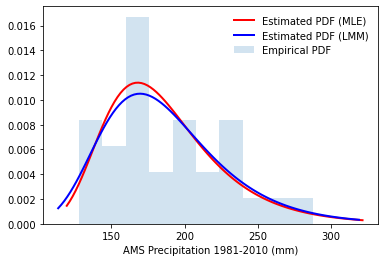

In [19]:
# 1981 - 2010: # Plot empirical PDF

plt.hist(ams81df["prcp"], density=True, histtype='stepfilled',
         alpha=0.2, label='Empirical PDF')

# Plot estimated PDF based on maximum likelihood method
bins = np.linspace(MLEGEV.ppf(0.01), MLEGEV.ppf(0.99), 100)
plt.plot(bins, MLEGEV.pdf(bins),
         'r-', lw=2, label='Estimated PDF (MLE)')

# Plot estimated PDF based on the method of L-moments
bins = np.linspace(LMMGEV.ppf(0.01), LMMGEV.ppf(0.99), 100)
plt.plot(bins, LMMGEV.pdf(bins),
         'b-', lw=2, label='Estimated PDF (LMM)')

plt.xlabel("AMS Precipitation 1981-2010 (mm)")
plt.legend(loc='best', frameon=False)
plt.show()

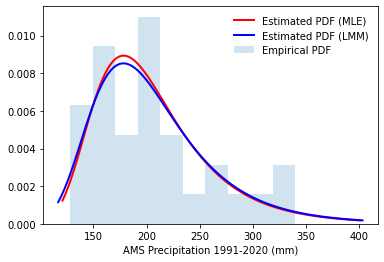

In [20]:
# 1991 - 2020 # Plot empirical PDF
plt.hist(ams91df["prcp"], density=True, histtype='stepfilled',
         alpha=0.2, label='Empirical PDF')

# Plot estimated PDF based on maximum likelihood method
bins = np.linspace(MLEGEV2.ppf(0.01), MLEGEV2.ppf(0.99), 100)
plt.plot(bins, MLEGEV2.pdf(bins),
         'r-', lw=2, label='Estimated PDF (MLE)')

# Plot estimated PDF based on the method of L-moments
bins = np.linspace(LMMGEV2.ppf(0.01), LMMGEV2.ppf(0.99), 100)
plt.plot(bins, LMMGEV2.pdf(bins),
         'b-', lw=2, label='Estimated PDF (LMM)')

plt.xlabel("AMS Precipitation 1991-2020 (mm)")
plt.legend(loc='best', frameon=False)
plt.show()

**Cumulative Distribution Function**

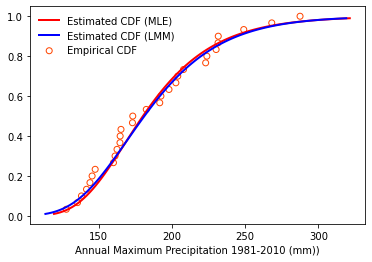

In [21]:
# 1981 - 2010 # CDF : 

# Plot empirical CDF
plt.scatter(ams81df["prcp"].sort_values(), np.arange(1, ams81df["prcp"].size+1, dtype=float)/ams81df["prcp"].size, color = 'orangered', facecolors='none', label='Empirical CDF')

# Plot estimated PDF based on maximum likelihood method
bins = np.linspace(MLEGEV.ppf(0.01), MLEGEV.ppf(0.99), 100)
plt.plot(bins, MLEGEV.cdf(bins), 'r-', lw=2, label='Estimated CDF (MLE)')

# Plot estimated PDF based on the method of L-moments
bins = np.linspace(LMMGEV.ppf(0.01), LMMGEV.ppf(0.99), 100)
plt.plot(bins, LMMGEV.cdf(bins), 'b-', lw=2, label='Estimated CDF (LMM)')

plt.xlabel("Annual Maximum Precipitation 1981-2010 (mm))")
plt.legend(loc='best', frameon=False)
plt.show()

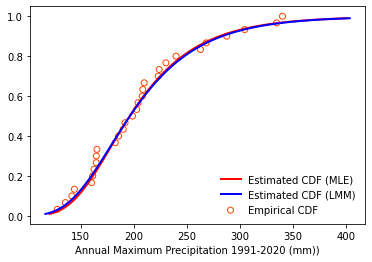

In [22]:
# 1991 - 2020 # CDF : 

# Plot empirical CDF
plt.scatter(ams91df["prcp"].sort_values(), np.arange(1, ams91df["prcp"].size+1, dtype=float)/ams91df["prcp"].size, color = 'orangered', facecolors='none', label='Empirical CDF')

# Plot estimated PDF based on maximum likelihood method
bins = np.linspace(MLEGEV2.ppf(0.01), MLEGEV2.ppf(0.99), 100)
plt.plot(bins, MLEGEV2.cdf(bins), 'r-', lw=2, label='Estimated CDF (MLE)')


# Plot estimated PDF based on the method of L-moments
bins = np.linspace(LMMGEV2.ppf(0.01), LMMGEV2.ppf(0.99), 100)
plt.plot(bins, LMMGEV2.cdf(bins), 'b-', lw=2, label='Estimated CDF (LMM)')

plt.xlabel("Annual Maximum Precipitation 1991-2020 (mm))")
plt.legend(loc='best', frameon=False)
plt.show()

## PDS-based point precipitation frequency estimates with 90% confidence intervals (inches)  

In [23]:
cstat = texasprcp81.sel(y=slice(30.64,30.65), x=slice(-96.3,-96.23))  ## pulls 30.62, -96.29 (nearest gridded data to college station)

# cstat = texasprcp91.sel(y=slice(30.64,30.65), x=slice(-96.3,-96.23))  ## pulls 30.62, -96.29 (nearest gridded data to college station)

**Precipitation Frequency Events for a 24 Hour event for College Station, Texas :**

In [26]:
## convert from inches to millimeters 
ari_1 = 3.32 * 25.4 #84.32 # 1 in 1 year event for a 24 hr duration
ari_2 = 4.26 * 25.4 #= 108.2
ari_5 = 5.57 * 25.4 #= 141.5
ari_10 = 6.84 * 25.4# = 173.7
ari_25 = 8.81 * 25.4 #= 223.8
ari_50 = 10.5 * 25.4 #= 266.7
ari_100 = 12.5 * 25.4 #= 317.5
ari_200 = 14.8 * 25.4 #= 375.9
ari_500 = 18.2 * 25.4 #= 462.3
ari_1000 = 21.0 * 25.4 #= 533.4

In [28]:
cstat_ari_1 = cstat.where(cstat > ari_1).sum(["y","x"]).to_dataframe()
cstat_ari_2 = cstat.where(cstat > ari_2).sum(["y","x"]).to_dataframe()
cstat_ari_5 = cstat.where(cstat > ari_5).sum(["y","x"]).to_dataframe()
cstat_ari_10 = cstat.where(cstat > ari_10).sum(["y","x"]).to_dataframe()
cstat_ari_25 = cstat.where(cstat > ari_10).sum(["y","x"]).to_dataframe()
cstat_ari_50 = cstat.where(cstat > ari_50).sum(["y","x"]).to_dataframe()
cstat_ari_100 = cstat.where(cstat > ari_100).sum(["y","x"]).to_dataframe()
cstat_ari_200 = cstat.where(cstat > ari_200).sum(["y","x"]).to_dataframe()
cstat_ari_500 = cstat.where(cstat > ari_500).sum(["y","x"]).to_dataframe()
cstat_ari_1000 = cstat.where(cstat > ari_1000).sum(["y","x"]).to_dataframe()

In [29]:
cstat_ari_1.index

DatetimeIndex(['1981-01-01', '1981-01-02', '1981-01-03', '1981-01-04',
               '1981-01-05', '1981-01-06', '1981-01-07', '1981-01-08',
               '1981-01-09', '1981-01-10',
               ...
               '2010-12-22', '2010-12-23', '2010-12-24', '2010-12-25',
               '2010-12-26', '2010-12-27', '2010-12-28', '2010-12-29',
               '2010-12-30', '2010-12-31'],
              dtype='datetime64[ns]', name='time', length=10957, freq=None)

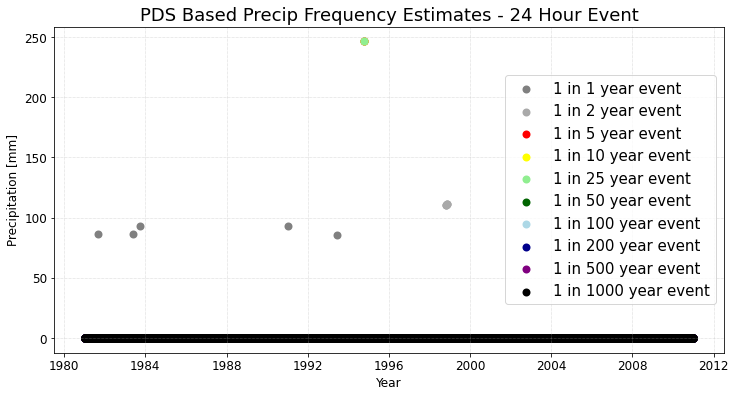

In [32]:
# Calculate Rolling Mean: 
#rolling = pds81_98df.rolling(min_periods = 2, window = 5, center=True).mean()
#rolling2 = pds91_98df.rolling(min_periods = 2, window = 5, center=True).mean()

# plot: 
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(cstat_ari_1.index, cstat_ari_1["prcp"], lw=2, color='grey', label = "1 in 1 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_2["prcp"], lw=2, color='darkgrey', label = "1 in 2 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_5["prcp"], lw=2, color='red', label = "1 in 5 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_10["prcp"], lw=2, color='yellow', label = "1 in 10 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_25["prcp"], lw=2, color='lightgreen', label = "1 in 25 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_50["prcp"], lw=2, color='darkgreen', label = "1 in 50 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_100["prcp"], lw=2, color='lightblue', label = "1 in 100 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_200["prcp"], lw=2, color='darkblue', label = "1 in 200 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_500["prcp"], lw=2, color= "purple", label = "1 in 500 year event")
ax.scatter(cstat_ari_1.index, cstat_ari_1000["prcp"], lw=2, color='black', label = "1 in 1000 year event")

# set tick label size for both x and y
ax.tick_params(labelsize=12)

# set x and y axis labels and title
ax.set_ylabel(r'Precipitation [mm]', fontsize=12);
ax.set_xlabel(r'Year', fontsize=12);
ax.set_title("PDS Based Precip Frequency Estimates - 24 Hour Event", fontsize=18)

# set grid
ax.grid(lw=0.5, ls="dotted")

# set legend
ax.legend(loc = "right", fontsize=15)

**Precipitation Frequency Events for a 3 day event for College Station, Texas :**

In [ ]:
## convert from inches to millimeters 
ari_1 = 4.11 * 25.4
ari_2 = 5.30 * 25.4
ari_5 = 6.96 * 25.4
ari_10 = 8.57 * 25.4
ari_25 = 11.0 * 25.4
ari_50 = 13.3 * 25.4
ari_100 = 15.7 * 25.4
ari_200 = 18.4 * 25.4
ari_500 = 22.1 * 25.4
ari_1000 = 25.1 * 25.4

**Precipitation Frequency Events for a 7 day Hour event for College Station, Texas :**

In [ ]:
## convert from inches to millimeters 
ari_1 = 5.10 * 25.4
ari_2 = 6.36 * 25.4
ari_5 = 8.21 * 25.4
ari_10 = 9.92 * 25.4
ari_25 = 12.4 * 25.4
ari_50 = 14.6 * 25.4
ari_100 = 16.9 * 25.4
ari_200 = 19.6 * 25.4
ari_500 = 23.3 * 25.4
ari_1000 = 26.5 * 25.4

# Partial Duration Series 

collection of peaks over a threshold (98th and 99th percentiles)

In [129]:
# Thresholds:

# 1981-2010:
threshold81_98 = 28.390625 # 98th percentile 
threshold81_99 = 38.9921875 # 99th percentile 

pds81_98 = texasprcp81.where(texasprcp81 > threshold81_98)
pds81_99 = texasprcp81.where(texasprcp81 > threshold81_99)


# 1991-2020:
threshold91_98 = 28.75 # 98th percentile 
threshold91_99 = 39.578125 # 99th percentile 

pds91_98 = texasprcp91.where(texasprcp91 > threshold91_98)
pds91_99 = texasprcp91.where(texasprcp91 > threshold91_99)

In [141]:
pds81_98df = pds81_98.mean(["y","x"]).to_dataframe()
pds91_98df = pds91_98.mean(["y","x"]).to_dataframe()

pds81_99df = pds81_99.mean(["y","x"]).to_dataframe()
pds91_99df = pds91_99.mean(["y","x"]).to_dataframe()

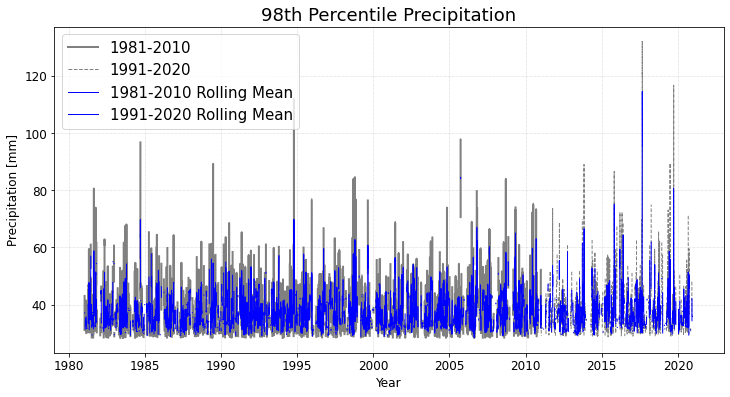

In [155]:
# Partial Duration Series for Texas in the 98th Percentile: 

# Calculate Rolling Mean: 
rolling = pds81_98df.rolling(min_periods = 2, window = 5, center=True).mean()
rolling2 = pds91_98df.rolling(min_periods = 2, window = 5, center=True).mean()

# plot: 
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pds81_98df["prcp"], lw=2, color='grey', label="1981-2010")
ax.plot(pds91_98df["prcp"], lw=1, color='grey', linestyle = "dashed", label="1991-2020")
ax.plot(rolling["prcp"], lw=1, color='blue', label="1981-2010 Rolling Mean")
ax.plot(rolling2["prcp"], lw=1, color='blue', label="1991-2020 Rolling Mean")


# set tick label size for both x and y
ax.tick_params(labelsize=12)

# set x and y axis labels and title
ax.set_ylabel(r'Precipitation [mm]', fontsize=12);
ax.set_xlabel(r'Year', fontsize=12);
ax.set_title("98th Percentile Precipitation", fontsize=18)

# set grid
ax.grid(lw=0.5, ls="dotted")

# set legend
ax.legend(fontsize=15)

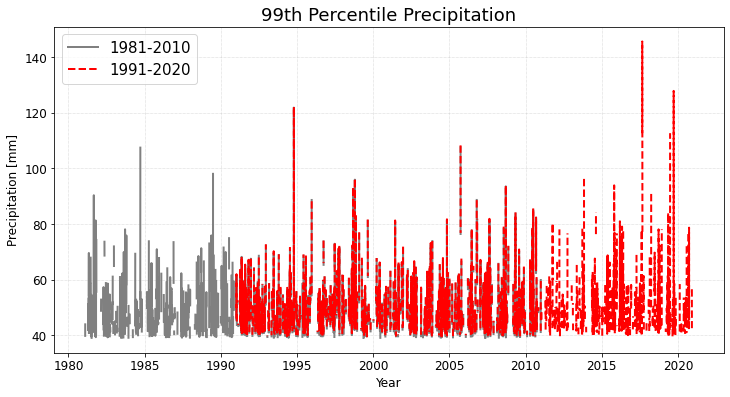

In [153]:
# Partial Duration Series for Texas in the 99th Percentile: 

# Calculate Rolling Mean: 
#rolling = pds81_99df.rolling(min_periods = 2, window = 5, center=True).mean()
#rolling2 = pds91_99df.rolling(min_periods = 2, window = 5, center=True).mean()

# plot: 
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pds81_99df["prcp"], lw=2, color='grey', label="1981-2010")
ax.plot(pds91_99df["prcp"], lw=2, color='red', linestyle = "dashed", label="1991-2020")
#ax.plot(rolling["prcp"], lw=1, color='red', label="1981-2010 Rolling Mean")
#ax.plot(rolling2["prcp"], lw=1, color='red', label="1991-2020 Rolling Mean")


# set tick label size for both x and y
ax.tick_params(labelsize=12)

# set x and y axis labels and title
ax.set_ylabel(r'Precipitation [mm]', fontsize=12);
ax.set_xlabel(r'Year', fontsize=12);
ax.set_title("99th Percentile Precipitation", fontsize=18)

# set grid
ax.grid(lw=0.5, ls="dotted")

# set legend
ax.legend(fontsize=15)

## **Annual Max Precipitation for west Texas and east Texas** 

Splitting Texas into west and east Texas - most of the extremes are caused by the east side of Texas, so it is not a good representation of the whole state as west Texas is much drier. 
Texas is split at -100 W  

In [93]:
west91tx = texasprcp91.sel(x=slice(-106.6,-100)).max(['y','x']).groupby("time.year").max()
east91tx = texasprcp91.sel(x=slice(-99.9,-93.52)).max(['y','x']).groupby("time.year").max()

west91txdf = west91tx.to_dataframe()
east91txdf = east91tx.to_dataframe()

In [94]:
westtx = texasprcp81.sel(x=slice(-106.6,-100)).max(['y','x']).groupby("time.year").max()
easttx = texasprcp81.sel(x=slice(-99.9,-93.52)).max(['y','x']).groupby("time.year").max()

westtxdf = westtx.to_dataframe()
easttxdf = easttx.to_dataframe()


west91tx = texasprcp91.sel(x=slice(-106.6,-100)).max(['y','x']).groupby("time.year").max()
east91tx = texasprcp91.sel(x=slice(-99.9,-93.52)).max(['y','x']).groupby("time.year").max()

west91txdf = west91tx.to_dataframe()
east91txdf = east91tx.to_dataframe()

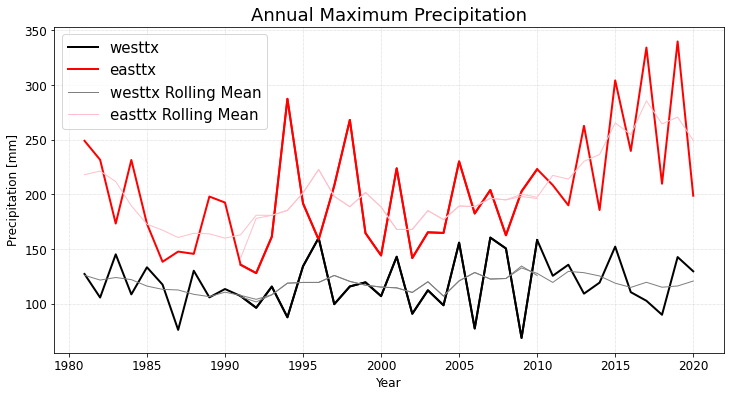

In [95]:
# Annual Maximum Precipitation for Texas: 

# Calculate Rolling Mean: 
rolling = westtxdf.rolling(min_periods = 2, window = 5, center=True).mean()
rolling2 = easttxdf.rolling(min_periods = 2, window = 5, center=True).mean()
rolling3 = west91txdf.rolling(min_periods = 2, window = 5, center=True).mean()
rolling4 = east91txdf.rolling(min_periods = 2, window = 5, center=True).mean()


# plot: 
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(westtxdf["prcp"], lw=2, color='black', label="westtx")
ax.plot(easttxdf["prcp"], lw=2, color='red', label="easttx")
ax.plot(west91txdf["prcp"], lw=2, color='black')
ax.plot(east91txdf["prcp"], lw=2, color='red')
ax.plot(rolling["prcp"], lw=1, color='grey', label="westtx Rolling Mean")
ax.plot(rolling2["prcp"], lw=1, color='pink', label="easttx Rolling Mean")
ax.plot(rolling3["prcp"], lw=1, color='grey')
ax.plot(rolling4["prcp"], lw=1, color='pink')

# set tick label size for both x and y
ax.tick_params(labelsize=12)

# set x and y axis labels and title
ax.set_ylabel(r'Precipitation [mm]', fontsize=12);
ax.set_xlabel(r'Year', fontsize=12);
ax.set_title("Annual Maximum Precipitation", fontsize=18)

# set grid
ax.grid(lw=0.5, ls="dotted")

# set legend
ax.legend(fontsize=15)

# Seasonal Averages


Spring, Summer, Fall, Winter

In [34]:
# Seasonal Precipitation: 
seas_prcp81 = texasprcp81.groupby('time.season').mean('time') # grouping precipitation data by season, and finding the mean precipitation for each grid cell during that season
seas_prcp91 = texasprcp91.groupby('time.season').mean('time')

In [35]:
# convert to panda dataframe : 
seas81df = seas_prcp81.to_dataframe()
seas91df = seas_prcp91.to_dataframe()

In [337]:
# where did the maximum precipitation occur during the 1981-2010 season? 
seas81df.query('prcp == prcp.max()')

,,,spatial_ref,prcp
season,y,x,,
JJA,30.0625,-93.729164,0,4.746547


In [338]:
# Quick Statistics about the 1981-2010 Seasonal Precipitation Data: 
seas81df.describe()

,spatial_ref,prcp
count,317520.0,149176.000000
mean,0.0,1.992775
std,0.0,0.946226
min,0.0,0.185134
25%,0.0,1.286347
50%,0.0,1.956476
75%,0.0,2.594714
max,0.0,4.746547


In [339]:
seas91df.describe()

,spatial_ref,prcp
count,317520.0,149176.000000
mean,0.0,1.986295
std,0.0,0.990376
min,0.0,0.150560
25%,0.0,1.233283
50%,0.0,1.925552
75%,0.0,2.638872
max,0.0,5.345366


In [36]:
# Seasonal Precipitation: 

# 1981-2010:
w81prcp = seas_prcp81.sel(season="DJF")
s81prcp = seas_prcp81.sel(season="MAM")
su81prcp = seas_prcp81.sel(season="JJA")
f81prcp = seas_prcp81.sel(season="SON")

# 1991-2020:
w91prcp = seas_prcp91.sel(season="DJF")
s91prcp = seas_prcp91.sel(season="MAM")
su91prcp = seas_prcp91.sel(season="JJA")
f91prcp = seas_prcp91.sel(season="SON")

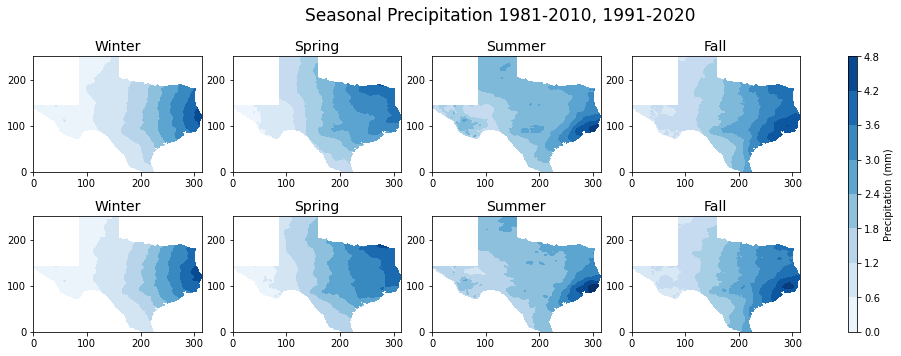

In [356]:
# Seasonal Precipitation: 

# Plot Fig: 
fig, axs = plt.subplots(2,4, figsize = (14,5))

# 1981-2010:
# Plot Winter, Spring, Summer, Fall: 
mappable = axs[0,0].contourf(w81prcp, cmap = "Blues", vmin=0, vmax=5)
axs[0,0].set_title("Winter", size = 14)

axs[0,1].contourf(s81prcp, cmap = "Blues", vmin=0, vmax=5)
axs[0,1].set_title("Spring", size = 14)

axs[0,2].contourf(su81prcp, cmap = "Blues", vmin=0, vmax=5)
axs[0,2].set_title("Summer", size = 14)

axs[0,3].contourf(f81prcp, cmap = "Blues", vmin=0, vmax=5)
axs[0,3].set_title("Fall", size = 14)


# 1991-2020:
# Plot Winter, Spring, Summer, Fall: 
axs[1,0].contourf(w91prcp, cmap = "Blues", vmin=0, vmax=5)
axs[1,0].set_title("Winter", size = 14)

axs[1,1].contourf(s91prcp, cmap = "Blues", vmin=0, vmax=5)
axs[1,1].set_title("Spring", size = 14)

axs[1,2].contourf(su91prcp, cmap = "Blues", vmin=0, vmax=5)
axs[1,2].set_title("Summer", size = 14)

axs[1,3].contourf(f91prcp, cmap = "Blues", vmin=0, vmax=5)
axs[1,3].set_title("Fall", size = 14)


# title: 
fig.suptitle("Seasonal Precipitation 1981-2010, 1991-2020", size = 17)
fig.tight_layout()

cb = plt.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

Seasonally, precipitation is greatest during the spring and fall. 

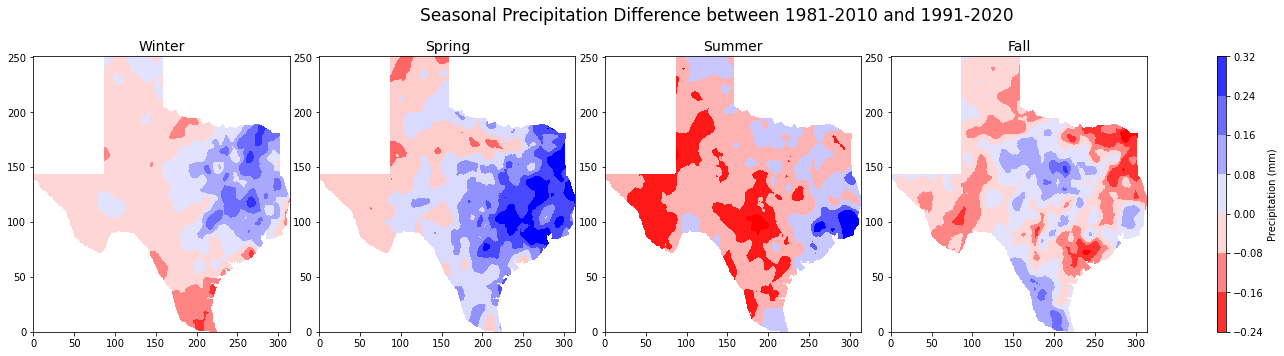

In [37]:
# Seasonal Precipitation Difference:
wprcpdif = w91prcp - w81prcp
sprcpdif = s91prcp - s81prcp
suprcpdif = su91prcp - su81prcp
fprcpdif = f91prcp - f81prcp


# Plot Fig: 
fig, axs = plt.subplots(1, 4, figsize = (20,5))
norm = TwoSlopeNorm(vcenter=0)

# Plot Winter, Spring, Summer, Fall: 
mappable = axs[0].contourf(wprcpdif, cmap = "bwr_r", norm=norm, vmin= -0.25, vmax=0.35)
axs[0].set_title("Winter", size = 14)

axs[1].contourf(sprcpdif, cmap = "bwr_r", norm=norm, vmin= -0.25, vmax=0.35)
axs[1].set_title("Spring", size = 14)

axs[2].contourf(suprcpdif, cmap = "bwr_r", norm=norm, vmin= -0.25, vmax=0.35)
axs[2].set_title("Summer", size = 14)

axs[3].contourf(fprcpdif, cmap = "bwr_r", norm=norm, vmin= -0.25, vmax=0.35)
axs[3].set_title("Fall", size = 14)

fig.suptitle("Seasonal Precipitation Difference between 1981-2010 and 1991-2020", size = 17)
fig.tight_layout()

cb = plt.colorbar(mappable, ax=axs, orientation = "vertical", aspect = 30, pad=0.05) # color bar
cb.set_label('Precipitation (mm)', fontsize=10) # color bar units

# Extra Notes:

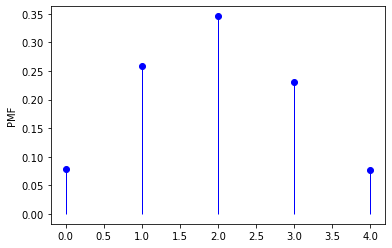

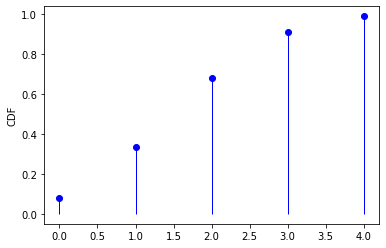

In [81]:
from scipy.stats import binom

n, p = 5, 0.4
distr = binom(n, p)  # frozen distribution
x = np.arange(0, 5)

PMF = distr.pmf(x)  # generate PMF in x
CDF = distr.cdf(x)  # generate CDF in x
MMS = distr.stats(moments='mvsk')  # obtain the four moments
RVS = distr.rvs(size=1000)  # generate random variates

plt.plot(x, PMF, 'bo')
plt.vlines(x, 0, PMF, 'b', lw=1)
plt.ylabel("PMF")
plt.show()

plt.plot(x, CDF, 'bo')
plt.vlines(x, 0, CDF, 'b', lw=1)
plt.ylabel("CDF")
plt.show()

In [ ]:
from scipy.stats import norm

bins = np.arange(5 - 3 * 2, 5 + 3 * 2, 0.01)

PDF = norm.pdf(bins, loc=5, scale=2)  # generate Probability Density Function in bins
CDF = norm.cdf(bins, loc=5, scale=2)  # generate Cumulative Distribution Function in bins
SF = norm.sf(bins, loc=5, scale=2)  # generate survival function (1-CDF)
PPF = norm.ppf(0.5, loc=5, scale=2)  # obtain percent point (inverse of CDF)
RVS = norm.rvs(loc=5, scale=2, size=1000)  # generate 1000 random variates
MMS = norm.stats(loc=5, scale=2, moments='mvsk')  # obtain the four moments

plt.plot(bins, PDF)
plt.ylabel("PDF")
plt.show()

plt.plot(bins, CDF)
plt.ylabel("CDF")
plt.show()

In [ ]:
# Plot: 
fig, ax = plt.subplots(2, figsize=(5, 6))

ax[0].hist(samples, density=True, histtype='stepfilled',  label='81')
ax[0].plot(bins, norm.pdf(bins, loc=mu, scale=sigma),'k-', lw=2, label='Fit')
ax[1].hist(sample2, density=True, histtype='stepfilled', label='91')
ax[1].plot(bins2, norm.pdf(bins2, loc=mu2, scale=sigma2),'k-', lw=2, label='Fit')


# set tick label size for both x and y
#ax.tick_params(labelsize=12)

# set x and y axis labels and title
#ax.set_ylabel(r'Precipitation [mm]', fontsize=12);
#ax.set_xlabel(r'Year', fontsize=12);
#ax.set_title("Annual Maximum Precipitation", fontsize=18)

# set grid, title, legend 
ax[0].grid(lw=0.5, ls="dotted")
ax[0].set_title("1981-2010 AMS Distribution")
ax[0].legend(fontsize=10)
ax[1].grid(lw=0.5, ls="dotted")
ax[1].set_title("1991-2020 AMS Distribution")
ax[1].legend(fontsize=10)

fig.tight_layout()

In [69]:
fig, ax = plt.subplots(figsize = (8, 6))

mappable = ax.contourf(wettest81yearma, cmap="tab20c_r", levels = np.arange(0,31,1), add_colorbar=False)  # shows the index of the wettest year  0 = 1981, 1 = 1999, etc. 

fig.suptitle("Wettest Year 1980-2010", size = 17)
fig.tight_layout() 

cb = fig.colorbar(mappable, ax=ax, orientation="vertical", shrink=0.7, pad=0.05, aspect=30)
cb.ax.set_yticklabels(labels1)

<xarray.DataArray 'prcp' (time: 10958, y: 252, x: 315)>
dask.array<getitem, shape=(10958, 252, 315), dtype=float64, chunksize=(31, 252, 315), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 26.02 26.06 26.1 26.15 ... 36.35 36.4 36.44 36.48
  * x            (x) float64 -106.6 -106.6 -106.5 -106.5 ... -93.6 -93.56 -93.52
  * time         (time) datetime64[ns] 1991-01-01 1991-01-02 ... 2020-12-31
    spatial_ref  int32 0

In [ ]:
# find thresholds:

print("Thresholds:")
print("1981-2010:")
# 98th percentile: 
threshold81_98 = np.percentile(texasprcp81, 98)
print("98th percentile:", threshold81_98)
# 99th percentile: 
threshold81_99 = np.percentile(texasprcp81, 99)
print("99th percentile:", threshold81_99)
print("1991-2020:")
# 98th percentile: 
threshold91_98 = np.percentile(texasprcp91, 98)
print("98th percentile:", threshold91_98)
# 99th percentile: 
threshold91_99 = np.percentile(texasprcp91, 99)
print("99th percentile:", threshold91_99)

98th

In [ ]:
## 98th 
# finding precipitation values greater than 98th percentile threshold:
pds81_98 = clim81['prcp'].where(clim81['prcp'] > (287-threshold81_98))
pds91_98 = clim91['prcp'].where(clim91['prcp'] > (356-threshold91_98))

# Pulls the mean precipitation value across grid cells over the 30-year period: 
thrs_mean_1981 = pds81_98.mean(['lat','lon']) # 1 value for every time step/1 value for all of Texas
thrs_mean_1991 = pds91_98.mean(['lat','lon'])

# pulls the mean value for each year: 
pds1981 = thrs_mean_1981.groupby("time.year").mean()
pds1991 = thrs_mean_1991.groupby("time.year").mean()

In [ ]:
# convert to panda dataframe to see the max. precipitation values for every year for Texas: 
pds1981df = pds1981.to_dataframe()
pds1991df = pds1991.to_dataframe()

99th 


In [ ]:
## 99th 
# finding precipitation values greater than 99th percentile threshold:
pds81_99 = clim81['prcp'].where(clim81['prcp'] > threshold81_99)
pds91_99 = clim91['prcp'].where(clim91['prcp'] > threshold91_99)

# Pulls the mean precipitation value across grid cells over the 30-year period: 
thrs_mean_1981 = pds81_99.mean(['lat','lon']) # 1 value for every time step/1 value for all of Texas
thrs_mean_1991 = pds91_99.mean(['lat','lon'])

# pulls the mean value for each year: 
pds1981_99 = thrs_mean_1981.groupby("time.year").mean()
pds1991_99 = thrs_mean_1991.groupby("time.year").mean()

In [ ]:
# convert to panda dataframe to see the max. precipitation values for every year for Texas: 
pds1981_99df = pds1981_99.to_dataframe()
pds1991_99df = pds1991_99.to_dataframe()